# Module 2.5: SNN-MPR Comparison

Visualise the error between the MPR and SNN for each target frequency. Take the best fits (fitness >0.1). 

SNN files are available at 

https://www.dropbox.com/scl/fo/vv7lx16wdb3tcnn125ar2/ACWugwhwcVYstGZ81TcVIWQ?rlkey=xo57pfu62afvy75ts7makyr11&e=1&st=3x9bk27n&dl=0

Until 02/05/2026 MPR files are available at 

https://filesender.renater.fr/?s=download&token=ed54b5d3-7022-476f-a2b9-27cc21ca3336

## 0.1 Import all built-in packages.

In [60]:
# Import necessary packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import zipfile
import seaborn as sns

import os
import datetime

# Import plotting style
from Figures.plotting_style import figure_style

figure_style()

({'snn': (0.10588235294117647, 0.6196078431372549, 0.4666666666666667),
  'mpr': (0.8509803921568627, 0.37254901960784315, 0.00784313725490196),
  'snn_ref': (0.4588235294117647, 0.4392156862745098, 0.7019607843137254),
  'mpr_fit': (0.9058823529411765, 0.1607843137254902, 0.5411764705882353),
  'snn_exc': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
  'snn_inh': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)},
 300)

Target frequency: 6 Hz, mean error = [np.float64(20.281731162628315), np.float64(34.13705254723404)]%
Target frequency: 10 Hz, mean error = [np.float64(10.280800359285118), np.float64(15.888007917127597)]%
Target frequency: 20 Hz, mean error = [np.float64(20.274030269730172), np.float64(19.315061637653663)]%
Target frequency: 60 Hz, mean error = [np.float64(31.83608440119243), np.float64(28.078952156550177)]%


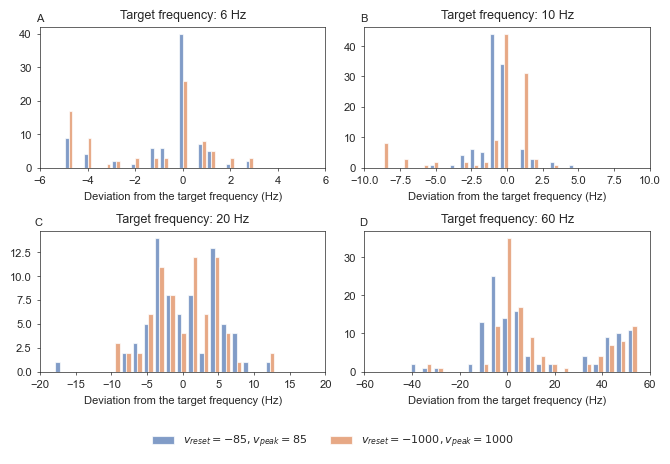

<Figure size 670x420 with 0 Axes>

In [ ]:
fig = plt.figure(figsize=(6.7, 4.2))

labels = [r'$v_{reset} = -85, v_{peak} = 85$', r'$v_{reset} = -1000, v_{peak} = 1000$']
axtext = ['A', 'B', 'C', 'D']
for cnt, target_freq in enumerate([6, 10, 20, 60]):
    xdata = []  
    mean_error = []
    for i, variationvrvt in enumerate(['Variation_VR_85_VT_85', 'Variation_VR_1000_VT_1000']):

        dataframe_file_name = 'param_freq_target_'+variationvrvt+'_'+str(target_freq)+'.csv'

        data = pd.read_csv(dataframe_file_name)
        # print(data.head())
        fits_errors = data.loc[data['fitness']< 0.1].copy()
        fits_errors.reset_index(drop = True, inplace = True)
        # print(fits_errors.head())

        xdata.append(fits_errors['fmax_MPR_exc'] - fits_errors['fmax_SNN_exc'])
        mean_error.append(np.mean(np.abs(fits_errors['error_freq_exc'])))
    
    print('Target frequency: ' + str(target_freq) + ' Hz, mean error = ' + str(mean_error) + '%')    

    # fig.add_subplot(2,2,cnt+1)
    ax = fig.add_subplot(2,2,cnt+1)
    ax.hist(xdata, bins=20, alpha=0.7)
    ax.set_xlabel('Deviation from the target frequency (Hz)')
    ax.set_title('Target frequency: ' + str(target_freq) + ' Hz')
    ax.set_xlim(-target_freq, target_freq)
    ax.text(0.01, 1.10, axtext[cnt], transform=ax.transAxes, va='top', ha='right')


fig.legend(
    labels=labels,
    loc='lower center',  # Position relative to the figure
    bbox_to_anchor=(0.5, -0.1),  # Adjust (x, y) offset
    ncol=2,  # Number of columns in the legend
    fancybox=True,
    shadow=True,
)
fig.tight_layout()

fig.savefig('Figures/error_range.png', bbox_inches='tight', dpi=600)


In [62]:
# Create a combined DataFrame for all target frequencies
all_data = []

for cnt, target_freq in enumerate([6, 10, 20, 60]):
    for variationvrvt in ['Variation_VR_85_VT_85', 'Variation_VR_1000_VT_1000']:
        dataframe_file_name = f'param_freq_target_{variationvrvt}_{target_freq}.csv'
        data = pd.read_csv(dataframe_file_name)

        fits_errors = data.loc[data['fitness'] < 0.1].copy()
        fits_errors.reset_index(drop=True, inplace=True)

        # Create normalized values for each parameter
        for param in ['ep_eta', 'ip_eta', 'ep_delta', 'ip_delta', 'sp_ge', 'sp_gi']:
            if len(fits_errors) > 0:  # Only proceed if there's data
                normalized_values = fits_errors[param] / np.max(fits_errors[param])
                for val in normalized_values:
                    all_data.append({
                        'Parameter': param,
                        'Normalized Value': val,
                        'Variation': variationvrvt,
                        'Target Frequency': target_freq
                    })

# Create DataFrame from collected data
df_plot = pd.DataFrame(all_data)

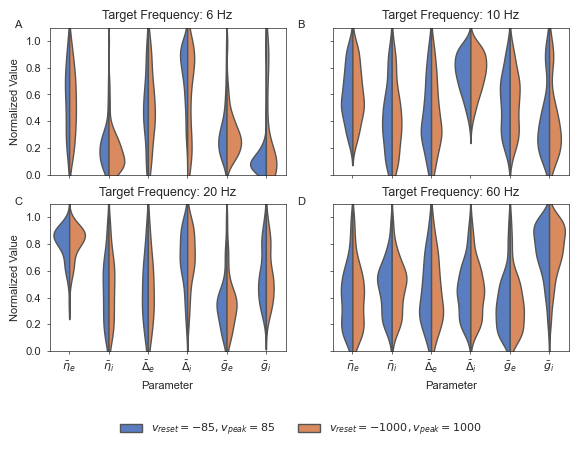

In [69]:
fig2, ax2 = plt.subplots(2, 2, figsize=(6.7, 4.2), sharex=True, sharey=True)
ax2 = ax2.flatten()
# fig2.suptitle('Normalized Parameter Distributions by Target Frequency')
custom_labels = [r'$\bar{\eta}_e$', r'$\bar{\eta}_i$',
                 r'$\bar{\Delta}_e$', r'$\bar{\Delta}_i$',
                 r'$\bar{g}_e$', r'$\bar{g}_i$']

for cnt, target_freq in enumerate([6, 10, 20, 60]):
    # Filter data for current target frequency
    current_data = df_plot[df_plot['Target Frequency'] == target_freq]

    # Create violin plot for this subplot
    sns.violinplot(
        data=current_data,
        x='Parameter',
        y='Normalized Value',
        hue='Variation',
        split=True,
        palette='muted',
        ax=ax2[cnt],
        legend=False,
        inner=None,  # This removes the inner error bars
    )

    ax2[cnt].set_title(f'Target Frequency: {target_freq} Hz')
    ax2[cnt].set_ylim(0, 1.1)    
    # Add subplot label (A, B, C, D)
    ax2[cnt].text(-0.15, 1.05, axtext[cnt], transform=ax2[cnt].transAxes,
                   va='top')

ax2[3].set_xticks(range(len(custom_labels)))
ax2[3].set_xticklabels(custom_labels)


fig2.legend(
    labels=labels,
    loc='lower center',  # Position relative to the figure
    bbox_to_anchor=(0.5, -0.12),  # Adjust (x, y) offset
    ncol=2,  # Number of columns in the legend
    fancybox=True,
    shadow=True,
)

fig.tight_layout()
fig.savefig('Figures/param_range.png', bbox_inches='tight', dpi=600)